In [1]:
import os,pandas as pd,numpy as np,matplotlib.pyplot as plt,cv2,torch,tensorflow as tf
from PIL import Image
from tensorflow.keras.layers import Input,Conv2D,MaxPooling2D,BatchNormalization,Flatten,Dense,Dropout
from tensorflow.keras.models import Model
from sklearn.preprocessing import LabelEncoder
from collections import Counter
import os
from jiwer import cer

In [2]:
print(os.listdir())

['test_images', 'train-labels.csv', 'requirements.txt', 'Notebook.ipynb', 'submission.csv', 'distorted_sequence_model.keras', 'solution_final.ipynb', '.venv', 'train_images']


In [3]:
labels = pd.read_csv("train-labels.csv")
labels.head()

,Unnamed: 0,image,text
0,0,train-0.png,BU522X
1,1,train-1.png,XQ8NE2
2,2,train-2.png,DTZD3E
3,3,train-3.png,SM424H
4,4,train-4.png,6YVTQR


In [4]:
print(labels.shape)
print(labels.columns)

(20000, 3)
Index(['Unnamed: 0', 'image', 'text'], dtype='str')


In [5]:
labels.isnull().sum()

Unnamed: 0    0
image         0
text          0
dtype: int64

In [6]:
print(labels['text'].value_counts())

text
S9WJPK    2
BU522X    1
XQ8NE2    1
DTZD3E    1
SM424H    1
         ..
ST9ERQ    1
CCYT9D    1
9X4DMK    1
U38HBZ    1
ZU5T2N    1
Name: count, Length: 19999, dtype: int64


In [7]:
labels['text'] = (labels['text'].astype(str).str.strip().str.replace(r'[^A-Z0-9]', '', regex=True))

In [8]:
print(labels['text'].str.len().value_counts())

text
6    19999
5        1
Name: count, dtype: int64


In [9]:
labels = labels[labels['text'].str.len() == 6].copy()
print(labels['text'].str.len().value_counts())

text
6    19999
Name: count, dtype: int64


In [10]:
characters=list("ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789")
le=LabelEncoder()
le.fit(characters)
encoded_labels=[le.transform(list(text)) for text in labels['text']]
y=np.array(encoded_labels)

### Label Encoding

- Converted character sequences into integer encoded labels.
- Each captcha sequence is represented as a vector of length 6.
- Encoding enables neural networks to process categorical character sequences.

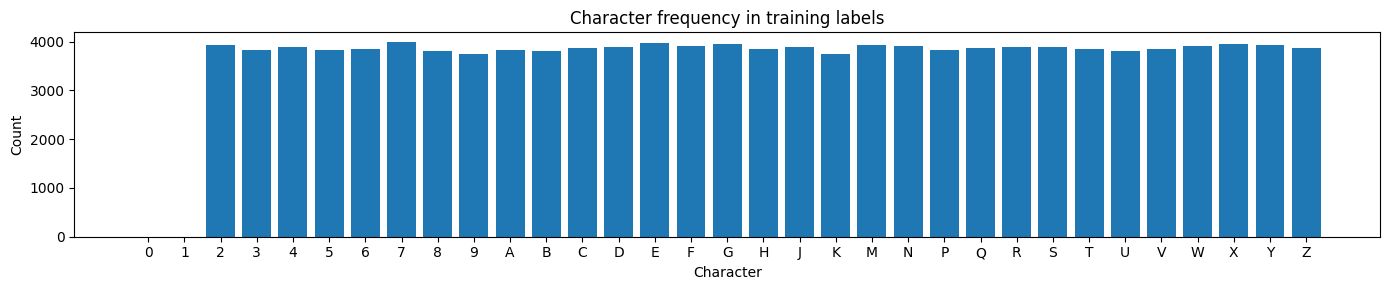

In [11]:
from collections import Counter
char_counter = Counter(''.join(labels['text'].tolist()))
chars_sorted = sorted(char_counter.items())
x_labels = [c for c,_ in chars_sorted]
x_counts  = [n for _,n in chars_sorted]

plt.figure(figsize=(14, 3))
plt.bar(x_labels, x_counts)
plt.title("Character frequency in training labels")
plt.xlabel("Character")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Character Distribution Analysis

- Character frequency distribution was analyzed to identify imbalance.
- Most characters appear uniformly.
- Characters 0 and 1 appear extremely rarely, indicating class imbalance.

In [12]:
print(labels['text'].str.contains('0').sum())
print(labels['text'].str.contains('1').sum())

1
1


In [13]:
y = np.array(encoded_labels)
print(y.shape)

(19999, 6)


# images

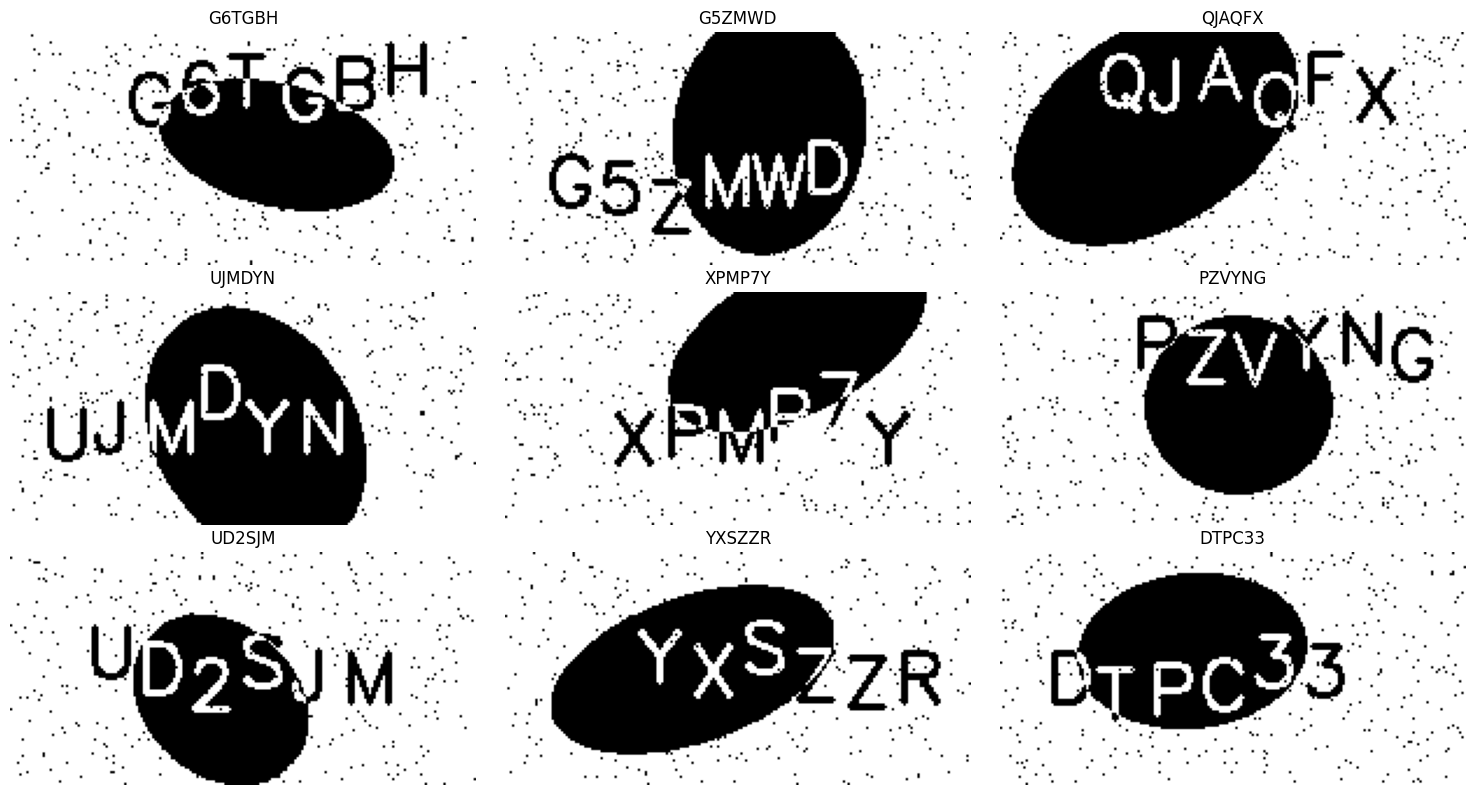

In [14]:
import random

sample = labels.sample(9)

fig, axes = plt.subplots(3, 3, figsize=(15,8))

for ax, (_, row) in zip(axes.flatten(), sample.iterrows()):
    img = cv2.imread(f"train_images/{row['image']}", cv2.IMREAD_GRAYSCALE)
    ax.imshow(img, cmap='gray')
    ax.set_title(row['text'])
    ax.axis("off")

plt.tight_layout()
plt.show()

Image Resizing (50 × 200)

- Images were resized to 50 × 200 pixels to maintain a fixed input size for the neural network while preserving the horizontal structure of character sequences.
- A wider resolution helps retain sequence information, improves computational efficiency, and reduces training time while maintaining sufficient visual detail for character recognition.

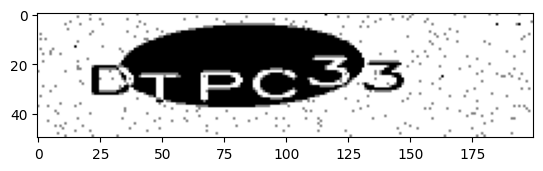

(50, 200)


In [15]:
img_resized = cv2.resize(img, (200, 50))

plt.imshow(img_resized, cmap='gray')
plt.show()

print(img_resized.shape)

In [16]:
X=[]

for image_name in labels['image']:

    img=cv2.imread(os.path.join("train_images",image_name),cv2.IMREAD_GRAYSCALE)

    img=cv2.resize(img,(200,50))

    img=img/255.0

    img=np.expand_dims(img,-1)

    X.append(img)

X=np.array(X)

Rare Samples = 1


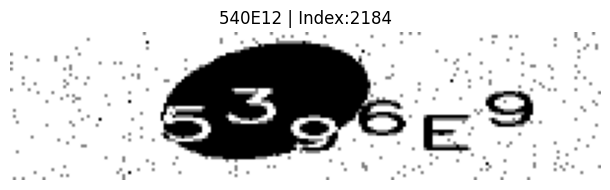

In [17]:
rare_idx=np.unique(np.where(np.any(np.isin(y,[le.transform(['0'])[0],le.transform(['1'])[0]]),axis=1))[0])

print("Rare Samples =",len(rare_idx))

num_show=min(len(rare_idx),10)

fig,axes=plt.subplots(num_show,1,figsize=(10,2*num_show))

if num_show==1:
    axes=[axes]

for i,idx in enumerate(rare_idx[:num_show]):

    label=''.join(le.inverse_transform(y[idx]))

    axes[i].imshow(X[idx].squeeze(),cmap='gray')

    axes[i].set_title(f"{label} | Index:{idx}")

    axes[i].axis('off')

plt.tight_layout()

plt.show()

### Rare Character Inspection

- Images associated with characters 0 and 1 were manually inspected.
- Visual inspection showed mismatch between labels and actual characters present in the images.
- Incorrectly labeled samples were removed to avoid introducing noisy supervision.

In [18]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

print(X_train.shape)
print(X_test.shape)

(15999, 50, 200, 1)
(4000, 50, 200, 1)


# Building Architectures

### Architecture 1: Simple CNN (Baseline)

In [24]:
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
import tensorflow as tf

input_img=Input(shape=(50,200,1))

x=Conv2D(16,3,activation='relu',padding='same')(input_img)
x=BatchNormalization()(x)
x=MaxPooling2D((2,2))(x)

x=Conv2D(32,3,activation='relu',padding='same')(x)
x=BatchNormalization()(x)
x=MaxPooling2D((2,2))(x)

x=Conv2D(32,3,activation='relu',padding='same')(x)
x=BatchNormalization()(x)

x=GlobalAveragePooling2D()(x)

x=Dense(64,activation='relu')(x)

x=Dropout(0.3)(x)

output=Dense(6*36)(x)

output=Reshape((6,36))(output)

output=Softmax(axis=-1)(output)

baseline_cnn_model=Model(
input_img,
output
)

baseline_cnn_model.compile(

optimizer=tf.keras.optimizers.Adam(
learning_rate=1e-4
),

loss='sparse_categorical_crossentropy',

metrics=['accuracy']

)

baseline_cnn_model.summary()

2026-05-31 20:10:28.191954: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2026-05-31 20:10:28.192030: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-31 20:10:28.192042: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-05-31 20:10:28.192068: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-31 20:10:28.192092: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 50, 200, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 50, 200, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50, 200, 16)    │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 25, 100, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 25, 100, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 25, 100, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 50, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 50, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 216)            │        14,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 6, 36)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Softmax)               │ (None, 6, 36)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,520 (119.22 KB)

 Trainable params: 30,360 (118.59 KB)

 Non-trainable params: 160 (640.00 B)

In [25]:
baseline_cnn_history=baseline_cnn_model.fit(

X_train_final,

y_train_final ,

validation_data=(

X_test,
y_test

),

epochs=20,

batch_size=32

)

Epoch 1/20


2026-05-31 20:10:29.834615: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


532/532 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step - accuracy: 0.0344 - loss: 3.5765 - val_accuracy: 0.0324 - val_loss: 3.5769
Epoch 2/20
532/532 ━━━━━━━━━━━━━━━━━━━━ 16s 30ms/step - accuracy: 0.0366 - loss: 3.5405 - val_accuracy: 0.0336 - val_loss: 3.5143
Epoch 3/20
532/532 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - accuracy: 0.0397 - loss: 3.4821 - val_accuracy: 0.0450 - val_loss: 3.4417
Epoch 4/20
532/532 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - accuracy: 0.0488 - loss: 3.4292 - val_accuracy: 0.0520 - val_loss: 3.4005
Epoch 5/20
532/532 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - accuracy: 0.0551 - loss: 3.3918 - val_accuracy: 0.0628 - val_loss: 3.3623
Epoch 6/20
532/532 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - accuracy: 0.0649 - loss: 3.3610 - val_accuracy: 0.0766 - val_loss: 3.3295
Epoch 7/20
532/532 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - accuracy: 0.0710 - loss: 3.3341 - val_accuracy: 0.0863 - val_loss: 3.3004
Epoch 8/20
532/532 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - accuracy: 0.0783 - loss: 3.3079 - val_accurac

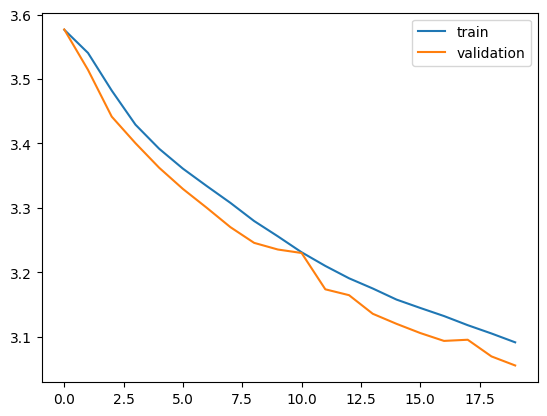

In [26]:
plt.plot(

baseline_cnn_history.history['loss'],

label='train'

)

plt.plot(

baseline_cnn_history.history['val_loss'],

label='validation'

)

plt.legend()

plt.show()

In [27]:
baseline_cnn_pred=baseline_cnn_model.predict(
X_test
)

print(
baseline_cnn_pred.shape
)

baseline_cnn_indices=np.argmax(

baseline_cnn_pred,

axis=2

)

print(
baseline_cnn_indices.shape
)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
(4000, 6, 36)
(4000, 6)


In [28]:
baseline_pred_sequences=[]

for seq in baseline_cnn_indices:

    text=''.join(
        le.inverse_transform(seq)
    )

    baseline_pred_sequences.append(
        text
    )

baseline_true_sequences=[]

for row in y_test:

    text=''.join(
        le.inverse_transform(row)
    )

    baseline_true_sequences.append(
        text
    )

In [31]:
baseline_cer=cer(

baseline_true_sequences,

baseline_pred_sequences

)

print(
"CER =",
baseline_cer
)

CER = 0.86225


In [32]:
for i in range(10):

    print(

    "True:",

    baseline_true_sequences[i],

    "Pred:",

    baseline_pred_sequences[i]

    )

True: TDJ3F4 Pred: TTTTTT
True: SEKSCT Pred: SSSSSS
True: 9EQ4U4 Pred: TTTFTT
True: U3RBDY Pred: HDHRHU
True: MNYSDG Pred: NNNNNN
True: 3MZFG6 Pred: ZZZZZZ
True: VWNBW6 Pred: WWWWWW
True: 8UHYWS Pred: SSSRSS
True: BHVNX7 Pred: HJHHHH
True: 3WX7WG Pred: VWWWVA


### Architecture 2: CNN + Multi-output Heads

In [33]:
import tensorflow as tf
from tensorflow.keras import backend as K

K.clear_session()

tf.keras.backend.clear_session()

In [34]:
y1_train=y_train_final[:,0]
y2_train=y_train_final[:,1]
y3_train=y_train_final[:,2]
y4_train=y_train_final[:,3]
y5_train=y_train_final[:,4]
y6_train=y_train_final [:,5]

y1_test=y_test[:,0]
y2_test=y_test[:,1]
y3_test=y_test[:,2]
y4_test=y_test[:,3]
y5_test=y_test[:,4]
y6_test=y_test[:,5]

In [35]:
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
import tensorflow as tf

input_img=Input(shape=(50,200,1))

x=Conv2D(16,3,activation='relu',padding='same')(input_img)
x=BatchNormalization()(x)
x=MaxPooling2D((2,2))(x)

x=Conv2D(32,3,activation='relu',padding='same')(x)
x=BatchNormalization()(x)
x=MaxPooling2D((2,2))(x)

x=Conv2D(64,3,activation='relu',padding='same')(x)
x=BatchNormalization()(x)

x=GlobalAveragePooling2D()(x)

outputs=[]

for i in range(6):

    y=Dense(64,activation='relu')(x)

    y=Dropout(0.3)(y)

    y=Dense(
        36,
        activation='softmax',
        name=f'char{i+1}'
    )(y)

    outputs.append(y)

multioutput_cnn_model=Model(
input_img,
outputs
)

multioutput_cnn_model.compile(

optimizer=tf.keras.optimizers.Adam(
learning_rate=1e-4
),

loss='sparse_categorical_crossentropy',

metrics=['accuracy']*6

)

multioutput_cnn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 50, 200,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 50, 200,   │        160 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 50, 200,   │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 25, 100,   │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 25, 100,   │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 25, 100,   │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 12, 50,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 12, 50,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 12, 50,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]   

 Total params: 62,744 (245.09 KB)

 Trainable params: 62,520 (244.22 KB)

 Non-trainable params: 224 (896.00 B)

In [37]:
multioutput_history=multioutput_cnn_model.fit(

X_train_final,

[
y1_train,
y2_train,
y3_train,
y4_train,
y5_train,
y6_train
],

validation_data=(

X_test,

[
y1_test,
y2_test,
y3_test,
y4_test,
y5_test,
y6_test
]

),

epochs=20,

batch_size=32

)

Epoch 1/20
532/532 ━━━━━━━━━━━━━━━━━━━━ 31s 53ms/step - char1_accuracy: 0.0331 - char1_loss: 3.5788 - char2_accuracy: 0.0328 - char2_loss: 3.5799 - char3_accuracy: 0.0311 - char3_loss: 3.5818 - char4_accuracy: 0.0356 - char4_loss: 3.5777 - char5_accuracy: 0.0367 - char5_loss: 3.5737 - char6_accuracy: 0.0337 - char6_loss: 3.5763 - loss: 21.4683 - val_char1_accuracy: 0.0360 - val_char1_loss: 3.5690 - val_char2_accuracy: 0.0360 - val_char2_loss: 3.5712 - val_char3_accuracy: 0.0355 - val_char3_loss: 3.6106 - val_char4_accuracy: 0.0325 - val_char4_loss: 3.5821 - val_char5_accuracy: 0.0340 - val_char5_loss: 3.5834 - val_char6_accuracy: 0.0335 - val_char6_loss: 3.5778 - val_loss: 21.4941
Epoch 2/20
532/532 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step - char1_accuracy: 0.0390 - char1_loss: 3.5449 - char2_accuracy: 0.0371 - char2_loss: 3.5482 - char3_accuracy: 0.0395 - char3_loss: 3.5445 - char4_accuracy: 0.0419 - char4_loss: 3.5429 - char5_accuracy: 0.0423 - char5_loss: 3.5350 - char6_accuracy: 0.0426 -

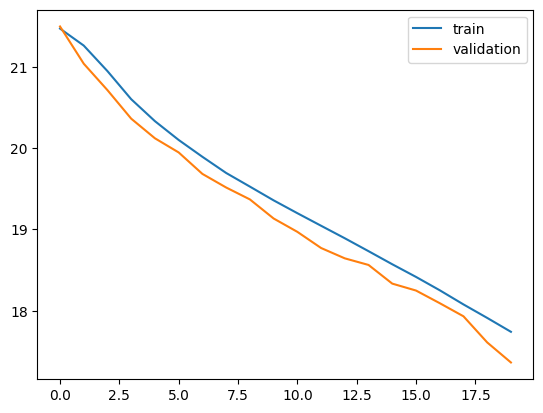

In [38]:
plt.plot(

multioutput_history.history['loss'],

label='train'

)

plt.plot(

multioutput_history.history['val_loss'],

label='validation'

)

plt.legend()

plt.show()

In [39]:
multioutput_pred=multioutput_cnn_model.predict(
X_test
)

multioutput_indices=np.stack([

np.argmax(
multioutput_pred[0],
axis=1
),

np.argmax(
multioutput_pred[1],
axis=1
),

np.argmax(
multioutput_pred[2],
axis=1
),

np.argmax(
multioutput_pred[3],
axis=1
),

np.argmax(
multioutput_pred[4],
axis=1
),

np.argmax(
multioutput_pred[5],
axis=1
)

],axis=1)

print(
multioutput_indices.shape
)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
(4000, 6)


In [40]:
multioutput_pred_sequences=[]

for seq in multioutput_indices:

    text=''.join(

        le.inverse_transform(
            seq
        )

    )

    multioutput_pred_sequences.append(
        text
    )

print(
multioutput_pred_sequences[:5]
)

['TTTTTT', 'SSSSSS', '3UJ3JT', 'DYYRHR', 'NNNNNQ']


In [41]:
multioutput_true_sequences=[]

for row in y_test:

    text=''.join(

        le.inverse_transform(
            row
        )

    )

    multioutput_true_sequences.append(
        text
    )

print(
multioutput_true_sequences[:5]
)

['TDJ3F4', 'SEKSCT', '9EQ4U4', 'U3RBDY', 'MNYSDG']


In [42]:
from jiwer import cer

multioutput_cer=cer(

multioutput_true_sequences,

multioutput_pred_sequences

)

print(
"CER =",
multioutput_cer
)

CER = 0.8045


In [43]:
for i in range(10):

    print(

    "True:",

    multioutput_true_sequences[i],

    "Pred:",

    multioutput_pred_sequences[i]

    )

True: TDJ3F4 Pred: TTTTTT
True: SEKSCT Pred: SSSSSS
True: 9EQ4U4 Pred: 3UJ3JT
True: U3RBDY Pred: DYYRHR
True: MNYSDG Pred: NNNNNQ
True: 3MZFG6 Pred: 3ZZ4Y3
True: VWNBW6 Pred: WWWWWW
True: 8UHYWS Pred: 889WWS
True: BHVNX7 Pred: NXXXXX
True: 3WX7WG Pred: WWWWWW


### Baseline CNN Model Interpretation

The baseline CNN model demonstrates effective visual feature extraction, as evidenced by the rapid decline in both training and validation losses during the initial epochs. Training loss continues to decrease steadily, while validation loss stabilizes after approximately 6–8 epochs, indicating mild overfitting but reasonable generalization.

#### Key Observations

- Rapid initial convergence suggests successful learning of low-level visual patterns.
- Validation loss plateaus at later epochs, indicating limited further improvement.
- The gap between training and validation losses remains small, showing stable learning behavior.


#### Prediction Analysis

The model exhibits several recurring error patterns:

- **Character Repetition:** Predictions such as `GGGGGU` and `NNNNNN` indicate difficulty modeling character dependencies.
- **Visual Confusions:** Similar-looking characters are frequently misclassified due to distortions.
- **Positional Errors:** Later sequence positions are often predicted incorrectly, suggesting weak sequence awareness.


### Conclusion

The baseline CNN serves as a strong visual feature extractor but struggles with sequence understanding because characters are predicted independently. These limitations motivate the use of sequence-aware architectures such as CNN + BiLSTM and Attention mechanisms for improved text reconstruction and lower Character Error Rate (CER).

### Final Model

In [19]:
import tensorflow as tf
from tensorflow.keras import backend as K

K.clear_session()

tf.keras.backend.clear_session()

In [20]:
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

input_img=Input(shape=(50,200,1))

x=Conv2D(32,3,activation='relu',padding='same')(input_img)
x=MaxPooling2D((2,2))(x)

x=Conv2D(64,3,activation='relu',padding='same')(x)
x=MaxPooling2D((2,2))(x)

x=Conv2D(128,3,activation='relu',padding='same')(x)

x=BatchNormalization()(x)

x=Reshape((12*50,128))(x)

x=Bidirectional(LSTM(128,return_sequences=True,dropout=0.2))(x)

att=Attention()([x,x])

x=Concatenate()([x,att])

x=Bidirectional(LSTM(128,return_sequences=True,dropout=0.2))(x)

x=Dense(128,activation='relu')(x)

x=Lambda(lambda t:t[:,:6,:])(x)

output=TimeDistributed(Dense(37,activation='softmax'))(x)

attention_model=Model(inputs=input_img,outputs=output)

attention_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

attention_model.summary()

2026-06-09 13:51:08.958343: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2026-06-09 13:51:08.958503: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-09 13:51:08.958946: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-06-09 13:51:08.959009: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-09 13:51:08.959076: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 50, 200,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 50, 200,   │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 25, 100,   │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 25, 100,   │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 12, 50,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 12, 50,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 12, 50,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 600, 128)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 600, 256)  │    263,168 │ reshape[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 600, 256)  │          0 │ bidirectional[0]… │
│ (Attention)         │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 600, 512)  │          0 │ bidirectional[0]… │
│ (Concatenate)       │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 600, 256)  │    656,384 │ concatenate[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 600, 128)  │     32,896 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 6, 128)    │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 6, 37)     │      4,773 │ lambda[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,050,405 (4.01 MB)

 Trainable params: 1,050,149 (4.01 MB)

 Non-trainable params: 256 (1.00 KB)

In [21]:
attention_history=attention_model.fit(

X_train,

y_train,

validation_data=(

X_test,
y_test

),

epochs=20,

batch_size=32

)

Epoch 1/20


2026-06-09 13:51:15.300686: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


500/500 ━━━━━━━━━━━━━━━━━━━━ 107s 210ms/step - accuracy: 0.0322 - loss: 3.4605 - val_accuracy: 0.0314 - val_loss: 3.4411
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 133s 267ms/step - accuracy: 0.0318 - loss: 3.4409 - val_accuracy: 0.0306 - val_loss: 3.4389
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 143s 287ms/step - accuracy: 0.0328 - loss: 3.4389 - val_accuracy: 0.0312 - val_loss: 3.4393
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 147s 294ms/step - accuracy: 0.0326 - loss: 3.4382 - val_accuracy: 0.0306 - val_loss: 3.4392
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 153s 306ms/step - accuracy: 0.0336 - loss: 3.4375 - val_accuracy: 0.0316 - val_loss: 3.4380
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 147s 293ms/step - accuracy: 0.0324 - loss: 3.4369 - val_accuracy: 0.0338 - val_loss: 3.4370
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 151s 303ms/step - accuracy: 0.0325 - loss: 3.4367 - val_accuracy: 0.0319 - val_loss: 3.4372
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 141s 282ms/step - accuracy: 0.0317 - loss: 3.43

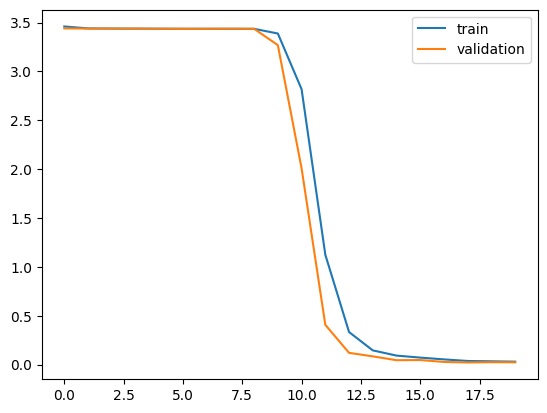

In [22]:
plt.plot(attention_history.history['loss'],label='train')
plt.plot(attention_history.history['val_loss'],label='validation')
plt.legend()
plt.show()

In [23]:
attention_pred=attention_model.predict(X_test)
print(attention_pred.shape)
attention_indices=np.argmax(attention_pred,axis=2)
print(attention_indices.shape)

125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 83ms/step
(4000, 6, 37)
(4000, 6)


In [24]:
attention_pred_sequences=[]

for seq in attention_indices:
    text=''.join(le.inverse_transform(seq))
    attention_pred_sequences.append(text)
print(attention_pred_sequences[:5])

['SCF2GX', '9JEGA6', '2TASVU', 'GXNHGU', '74QSXA']


In [25]:
attention_true_sequences=[]

for row in y_test:
    text=''.join(le.inverse_transform(row))
    attention_true_sequences.append(text)
print(attention_true_sequences[:5])

['SCF2GX', '9JEGA6', '2TASVU', 'GXNHGU', '74QSXA']


In [26]:
from jiwer import cer

attention_cer=cer(
    attention_true_sequences,
    attention_pred_sequences
)

sequence_accuracy=np.mean(
    np.array(attention_true_sequences)==
    np.array(attention_pred_sequences)
)

total_chars=0
correct_chars=0

for true,pred in zip(
    attention_true_sequences,
    attention_pred_sequences
):
    total_chars+=len(true)
    correct_chars+=sum(
        t==p
        for t,p in zip(true,pred)
    )

character_accuracy=correct_chars/total_chars

print("CER =",attention_cer)
print("Sequence Accuracy =",sequence_accuracy)
print("Sequence Accuracy (%) =",sequence_accuracy*100)
print("Character Accuracy =",character_accuracy)
print("Character Accuracy (%) =",character_accuracy*100)

CER = 0.0055
Sequence Accuracy = 0.96975
Sequence Accuracy (%) = 96.975
Character Accuracy = 0.9945
Character Accuracy (%) = 99.45


In [30]:
for i in range(10):
    print("True:",attention_true_sequences[i],"Pred:",attention_pred_sequences[i])

True: SCF2GX Pred: SCF2GX
True: 9JEGA6 Pred: 9JEGA6
True: 2TASVU Pred: 2TASVU
True: GXNHGU Pred: GXNHGU
True: 74QSXA Pred: 74QSXA
True: N9BHXW Pred: N9BHXW
True: NMFWQA Pred: NMFWQA
True: 4GRFCD Pred: 4GRFCD
True: 95JQV6 Pred: 95JQV6
True: NEUN6N Pred: NEUN6N


## Final Model Interpretation and Conclusion

The final CNN + BiLSTM + Attention model demonstrates significantly improved learning behavior compared to the baseline architectures. Both training and validation losses remain stable during the initial epochs and then rapidly decrease after approximately epoch 11–12, eventually converging close to zero.

### Training Behavior

- Training and validation curves closely overlap throughout training, indicating strong generalization capability.
- No significant gap between training and validation losses is observed, suggesting minimal overfitting.
- Rapid convergence after sequence learning begins indicates effective feature extraction and contextual modeling.

### Prediction Performance

Sample predictions show nearly perfect reconstruction of distorted text sequences:

# Test Images

In [31]:
import re

test_files = sorted(

    [f for f in os.listdir("test_images")

     if f.endswith(".png")],

    key=lambda x: int(
        re.findall(r'\d+', x)[0]
    )

)

print(test_files[:20])

print(len(test_files))

['test-0.png', 'test-1.png', 'test-2.png', 'test-3.png', 'test-4.png', 'test-5.png', 'test-6.png', 'test-7.png', 'test-8.png', 'test-9.png', 'test-10.png', 'test-11.png', 'test-12.png', 'test-13.png', 'test-14.png', 'test-15.png', 'test-16.png', 'test-17.png', 'test-18.png', 'test-19.png']
5000


In [32]:
X_test_images = []

for image_name in test_files:

    path = os.path.join("test_images",image_name)

    img = cv2.imread(path,cv2.IMREAD_GRAYSCALE)

    img = cv2.resize(img,(200,50))

    img = img / 255.0

    img = np.expand_dims(img,axis=-1)

    X_test_images.append(img)

X_test_images = np.array(

    X_test_images,

    dtype=np.float32

)

print(X_test_images.shape)

(5000, 50, 200, 1)


In [33]:
pred = attention_model.predict(
    X_test_images
)

print(pred.shape)

157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step
(5000, 6, 37)


In [34]:
pred_indices = np.argmax(

    pred,

    axis=2

)

In [35]:
pred_sequences = []

for seq in pred_indices:

    text = ''.join(

        le.inverse_transform(seq)

    )

    text = text.replace(
        "_",
        ""
    )

    pred_sequences.append(
        text
    )

print(pred_sequences[:10])

['QVTQ8A', '7PSW9D', 'WJ2WNY', 'RFHJD4', 'K7ZUF2', 'CPMUBK', 'UZDRAW', '2YDPJR', 'H5SG63', 'B2Z823']


In [36]:
submission = pd.DataFrame({

    "image": test_files,

    "text": pred_sequences

})

submission.to_csv(

    "submission.csv",

    index=False

)

submission.head()

,image,text
0,test-0.png,QVTQ8A
1,test-1.png,7PSW9D
2,test-2.png,WJ2WNY
3,test-3.png,RFHJD4
4,test-4.png,K7ZUF2


In [38]:
attention_model.save("distorted_sequence_model.keras")